# Loan Default Prediction using PyTorch

## Objective

Build a Multi-Layer Perceptron (MLP) using PyTorch for Loan Default Prediction by converting the cleaned dataset into tensors and training the model using a manual training loop.

# Import Libraries

In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# Set Random Seed

In [2]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print("Random Seed Set Successfully!")

Random Seed Set Successfully!


# Load Dataset

In [4]:
df = pd.read_csv("train_ctrUa4K.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# Data Cleaning

In [5]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Married"] = df["Married"].fillna(df["Married"].mode()[0])
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])

df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

df.drop("Loan_ID", axis=1, inplace=True)

# Encode Categorical Features

In [6]:
encoder = LabelEncoder()

categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

# Split Dataset

In [7]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Balance Training Data using SMOTE

In [8]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print(X_train.shape)
print(y_train.shape)

(674, 11)
(674,)


# Convert Data into PyTorch Tensors

In [9]:
X_train = torch.FloatTensor(X_train.values)
X_test = torch.FloatTensor(X_test.values)

y_train = torch.LongTensor(y_train.values)
y_test = torch.LongTensor(y_test.values)

print(X_train.shape)
print(y_train.shape)

torch.Size([674, 11])
torch.Size([674])


C:\Users\HEC\AppData\Local\Temp\ipykernel_3056\3431909480.py:4: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_train = torch.LongTensor(y_train.values)


# Build Multi-Layer Perceptron (MLP)

In [10]:
class LoanMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(X_train.shape[1], 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 2)
        )

    def forward(self, x):
        return self.network(x)


model = LoanMLP()

print(model)

LoanMLP(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
)


# Define Loss Function and Optimizer

In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the Model

In [12]:
epochs = 20

losses = []

for epoch in range(epochs):

    outputs = model(X_train)

    loss = criterion(outputs, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {loss.item():.4f}")

Epoch [1/20] Loss: 35.5969
Epoch [2/20] Loss: 33.0084
Epoch [3/20] Loss: 30.4715
Epoch [4/20] Loss: 27.9905
Epoch [5/20] Loss: 25.6396
Epoch [6/20] Loss: 23.4660
Epoch [7/20] Loss: 21.4584
Epoch [8/20] Loss: 19.6293
Epoch [9/20] Loss: 17.9913
Epoch [10/20] Loss: 16.4656
Epoch [11/20] Loss: 15.0443
Epoch [12/20] Loss: 13.7301
Epoch [13/20] Loss: 12.5070
Epoch [14/20] Loss: 11.3459
Epoch [15/20] Loss: 10.2478
Epoch [16/20] Loss: 9.1969
Epoch [17/20] Loss: 8.2094
Epoch [18/20] Loss: 7.3227
Epoch [19/20] Loss: 6.5798
Epoch [20/20] Loss: 6.0888


# Plot Training Loss

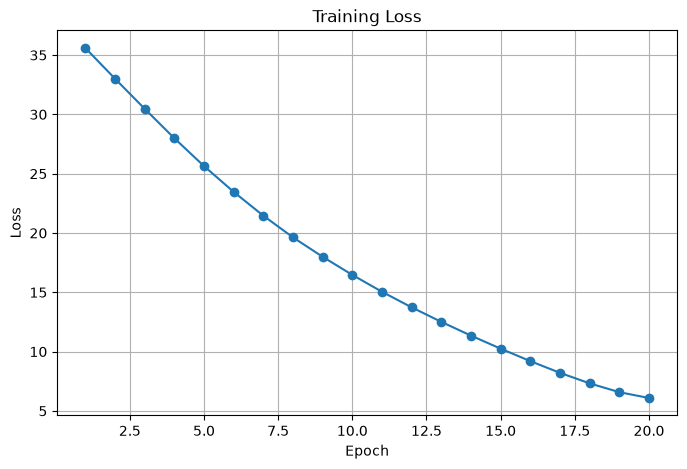

In [13]:
plt.figure(figsize=(8,5))

plt.plot(range(1, epochs + 1), losses, marker="o")

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

# Evaluate Model

In [14]:
with torch.no_grad():

    outputs = model(X_test)

    _, predicted = torch.max(outputs, 1)

    accuracy = (predicted == y_test).sum().item() / len(y_test)

print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.6423


# Conclusion

The Multi-Layer Perceptron (MLP) was successfully built and trained using PyTorch. The model learned through a manual training loop consisting of forward propagation, loss calculation, backpropagation, and optimizer updates over 20 epochs. The decreasing training loss indicates that the network successfully learned patterns from the loan default dataset.